# 06 Deep Learning — Data Loading & Text Preprocessing

⚠️ **IMPORTANT: DO NOT RE-RUN THIS NOTEBOOK ACCIDENTALLY**

This notebook downloads ~100 k conversations from Hugging Face and saves
preprocessed tensors to `results/`.  Only re-run if you need fresh data.

---

## Purpose

Prepare the raw SaaS sales conversation text for two deep learning models:

1. **Custom word-level tokenizer** → padded integer tensors (for BiLSTM)
2. **HuggingFace WordPiece tokenizer** → input_ids + attention_mask (for DistilBERT)

The same **stratified 80/20 split** (`random_state=42`) from Phase 1 is used so that
all models are evaluated on an identical test set.

### Outputs saved to `results/`

| File | Contents |
|------|----------|
| `dl_train_ids.pt` / `dl_val_ids.pt` / `dl_test_ids.pt` | Padded word-level token tensors |
| `dl_y_train.npy` / `dl_y_val.npy` / `dl_y_test.npy` | Label arrays |
| `dl_bert_train.pt` / `dl_bert_val.pt` / `dl_bert_test.pt` | DistilBERT tokenizer outputs |
| `dl_tokenizer.json` | Custom tokenizer vocabulary |

## 1. Imports and Setup

In [2]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_ROOT = Path('.').resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_preparation import run_data_preparation
from src.deep_learning import TokenizerConfig, SalesTokenizer

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = PROJECT_ROOT / 'figures'
for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(exist_ok=True)

print(f'PyTorch {torch.__version__}')
print(f'Project root: {PROJECT_ROOT}')

PyTorch 2.11.0
Project root: /Users/bhavanishanker/predictive-sales-analytics-engine


## 2. Load Dataset from Hugging Face

We load the **same dataset** (`DeepMostInnovations/saas-sales-conversations`) used
throughout Phase 1.  The cleaning pipeline in `src/data_preparation.py` handles
missing values, duplicates, and type coercion.

In [3]:
print('Loading dataset from Hugging Face...')
df = run_data_preparation()

TEXT_COL = 'full_text' if 'full_text' in df.columns else 'conversation_text'
TARGET_COL = 'outcome'

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors='coerce')
df = df.dropna(subset=[TEXT_COL, TARGET_COL]).copy()
df[TARGET_COL] = df[TARGET_COL].astype(int)

texts = np.array(df[TEXT_COL].fillna('').astype(str).tolist())
labels = df[TARGET_COL].to_numpy(dtype=int)

print(f'\nDataset: {len(texts):,} samples')
print(f'Text column: {TEXT_COL}')
print(f'Class distribution: Lost={np.sum(labels==0):,}  Won={np.sum(labels==1):,}')

Loading dataset from Hugging Face...



=== BASIC DATASET INFO ===
Shape: (100000, 3089)

Columns:
['company_id', 'company_name', 'product_name', 'product_type', 'conversation_id', 'scenario', 'conversation', 'full_text', 'outcome', 'conversation_length', 'customer_engagement', 'sales_effectiveness', 'probability_trajectory', 'conversation_style', 'conversation_flow', 'communication_channel', 'embedding_0', 'embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5', 'embedding_6', 'embedding_7', 'embedding_8', 'embedding_9', 'embedding_10', 'embedding_11', 'embedding_12', 'embedding_13', 'embedding_14', 'embedding_15', 'embedding_16', 'embedding_17', 'embedding_18', 'embedding_19', 'embedding_20', 'embedding_21', 'embedding_22', 'embedding_23', 'embedding_24', 'embedding_25', 'embedding_26', 'embedding_27', 'embedding_28', 'embedding_29', 'embedding_30', 'embedding_31', 'embedding_32', 'embedding_33', 'embedding_34', 'embedding_35', 'embedding_36', 'embedding_37', 'embedding_38', 'embedding_39', 'embedding_40

## 3. Train / Val / Test Split

| Split | Size | Purpose |
|-------|------|---------|
| **Train** | 72 % | Model training |
| **Val** | 8 % | Early stopping & LR scheduling |
| **Test** | 20 % | Final evaluation (identical to Phase 1) |

The **first split** (`test_size=0.2, random_state=42, stratify`) matches Phase 1
notebooks 04/05 exactly, so the test set is identical.

In [4]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels,
)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_text, y_train, test_size=0.1, random_state=42, stratify=y_train,
)

print(f'Train: {len(X_train_text):,}  |  Val: {len(X_val_text):,}  |  Test: {len(X_test_text):,}')
print(f'\nClass balance (train): Lost={np.sum(y_train==0):,}  Won={np.sum(y_train==1):,}')

Train: 72,000  |  Val: 8,000  |  Test: 20,000

Class balance (train): Lost=36,051  Won=35,949


## 4. Text Statistics

Understanding text length distribution is critical for choosing `max_length`
(truncation) and anticipating where models may struggle on very short or very
long conversations.

Word-count statistics (training set):
  Min:          87
  Mean:        220
  Median:      216
  95th %%:      294
  Max:         491
  Texts > 512 words: 0 (0.0%)


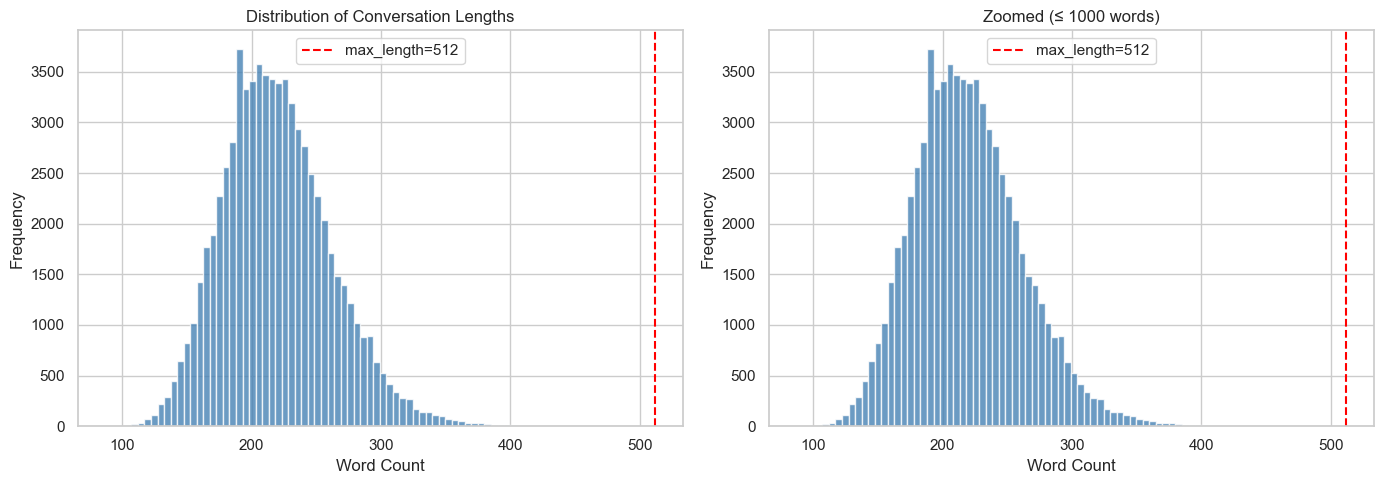

Saved: figures/dl_text_length_distribution.png


In [5]:
train_word_counts = np.array([len(t.split()) for t in X_train_text])

print('Word-count statistics (training set):')
print(f'  Min:    {train_word_counts.min():>8,}')
print(f'  Mean:   {train_word_counts.mean():>8,.0f}')
print(f'  Median: {np.median(train_word_counts):>8,.0f}')
print(f'  95th %%: {np.percentile(train_word_counts, 95):>8,.0f}')
print(f'  Max:    {train_word_counts.max():>8,}')
print(f'  Texts > 512 words: {(train_word_counts > 512).sum():,} '
      f'({(train_word_counts > 512).mean():.1%})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_word_counts, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(512, color='red', linestyle='--', label='max_length=512')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Conversation Lengths')
axes[0].legend()

axes[1].hist(train_word_counts[train_word_counts <= 1000], bins=80,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(512, color='red', linestyle='--', label='max_length=512')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Zoomed (≤ 1000 words)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_text_length_distribution.png')

## 5. Custom Word-Level Tokenizer (for BiLSTM)

### Design choices

| Choice | Rationale |
|--------|-----------|
| **Word-level** (not sub-word) | SaaS jargon like *"upsell"*, *"ARR"*, *"churn"* is preserved as single tokens; sub-word tokenizers would fragment them |
| **`min_freq=2`** | Removes typos and singleton tokens that add noise |
| **`max_vocab=30,000`** | Covers >99 % of running tokens in a business-English corpus while keeping the embedding matrix practical |
| **`max_length=512`** | Truncates very long conversations; empirically, opening and closing language is the most predictive |
| **Fit on training set only** | Prevents data leakage from validation/test vocabularies |

In [6]:
tok_config = TokenizerConfig(max_vocab=30_000, max_length=512, min_freq=2)
tokenizer = SalesTokenizer(tok_config)
tokenizer.fit(X_train_text.tolist())

print(f'Vocabulary size: {tokenizer.vocab_size:,}')
print(f'Special tokens: PAD=0, UNK=1')
print(f'Max sequence length: {tok_config.max_length}')

# Show sample tokenization
sample = X_train_text[0][:200]
sample_ids = tokenizer.encode(sample)
print(f'\nSample text (first 200 chars):\n  {sample}')
print(f'\nToken IDs (first 20): {sample_ids[:20]}')

Vocabulary size: 28,903
Special tokens: PAD=0, UNK=1
Max sequence length: 512

Sample text (first 200 chars):
  Hey, so I was looking into some tools to help with our hiring process... kinda feeling overwhelmed with everything. Like, the time-to-hire is getting ridiculous 😩. I'm wondering if there's something t

Token IDs (first 20): [46, 26, 2, 150, 81, 67, 57, 88, 5, 25, 13, 21, 804, 1712, 28, 1005, 469, 13, 480, 12]


In [7]:
# Tokenize and pad all three splits
print('Tokenizing train split...')
train_ids = tokenizer.encode_batch(X_train_text.tolist())
print('Tokenizing val split...')
val_ids = tokenizer.encode_batch(X_val_text.tolist())
print('Tokenizing test split...')
test_ids = tokenizer.encode_batch(X_test_text.tolist())

print(f'\nTensor shapes:')
print(f'  Train: {train_ids.shape}')
print(f'  Val:   {val_ids.shape}')
print(f'  Test:  {test_ids.shape}')

# Effective sequence length stats (non-padding)
train_seq_lens = (train_ids != 0).sum(dim=1).float()
print(f'\nEffective sequence lengths (after tokenization):')
print(f'  Mean: {train_seq_lens.mean():.0f}  Median: {train_seq_lens.median():.0f}  '
      f'Max: {train_seq_lens.max():.0f}')

Tokenizing train split...
Tokenizing val split...
Tokenizing test split...

Tensor shapes:
  Train: torch.Size([72000, 491])
  Val:   torch.Size([8000, 488])
  Test:  torch.Size([20000, 475])

Effective sequence lengths (after tokenization):
  Mean: 220  Median: 216  Max: 491


## 6. DistilBERT Tokenization (WordPiece)

DistilBERT uses a **sub-word tokenizer** (WordPiece, 30 522 vocab) from the
pretrained checkpoint.  Unlike our custom tokenizer, it can handle any word by
splitting it into known sub-units (e.g., *"upselling"* → *"ups"*, *"##elling"*).

We tokenize the **full test set** but only a **20 k training subset** for
DistilBERT to keep fine-tuning feasible on student hardware.

In [8]:
from transformers import DistilBertTokenizerFast
BERT_TRAIN_SIZE = 2000  # was 20,000
BERT_VAL_SIZE   = 500   # was 2,000
MAX_LEN = 512


# Subsample for DistilBERT
if len(X_train_text) > BERT_TRAIN_SIZE:
    bert_train_text, _, bert_train_labels, _ = train_test_split(
        X_train_text, y_train,
        train_size=BERT_TRAIN_SIZE, random_state=42, stratify=y_train,
    )
else:
    bert_train_text, bert_train_labels = X_train_text, y_train

if len(X_val_text) > BERT_VAL_SIZE:
    bert_val_text, _, bert_val_labels, _ = train_test_split(
        X_val_text, y_val,
        train_size=BERT_VAL_SIZE, random_state=42, stratify=y_val,
    )
else:
    bert_val_text, bert_val_labels = X_val_text, y_val

print(f'DistilBERT subsets — Train: {len(bert_train_text):,}  Val: {len(bert_val_text):,}')
print(f'Test: {len(X_test_text):,} (full)')

DistilBERT subsets — Train: 2,000  Val: 500
Test: 20,000 (full)


In [9]:
bert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

print('Tokenizing for DistilBERT (this may take a minute)...')
bert_train_enc = bert_tokenizer(
    bert_train_text.tolist(), truncation=True, padding='max_length',
    max_length=MAX_LEN, return_tensors='pt',
)
bert_val_enc = bert_tokenizer(
    bert_val_text.tolist(), truncation=True, padding='max_length',
    max_length=MAX_LEN, return_tensors='pt',
)
bert_test_enc = bert_tokenizer(
    X_test_text.tolist(), truncation=True, padding='max_length',
    max_length=MAX_LEN, return_tensors='pt',
)

print(f'\nShapes:')
print(f'  Train input_ids: {bert_train_enc["input_ids"].shape}')
print(f'  Val input_ids:   {bert_val_enc["input_ids"].shape}')
print(f'  Test input_ids:  {bert_test_enc["input_ids"].shape}')

Tokenizing for DistilBERT (this may take a minute)...

Shapes:
  Train input_ids: torch.Size([2000, 512])
  Val input_ids:   torch.Size([500, 512])
  Test input_ids:  torch.Size([20000, 512])


## 7. Save Preprocessed Artifacts

All tensors and labels are saved so that the training and evaluation notebooks
can load them without re-downloading or re-tokenizing.

In [10]:
# Word-level token tensors
torch.save(train_ids, RESULTS_DIR / 'dl_train_ids.pt')
torch.save(val_ids,   RESULTS_DIR / 'dl_val_ids.pt')
torch.save(test_ids,  RESULTS_DIR / 'dl_test_ids.pt')

# Labels
np.save(RESULTS_DIR / 'dl_y_train.npy', y_train)
np.save(RESULTS_DIR / 'dl_y_val.npy',   y_val)
np.save(RESULTS_DIR / 'dl_y_test.npy',  y_test)

# DistilBERT encodings
torch.save(bert_train_enc, RESULTS_DIR / 'dl_bert_train.pt')
torch.save(bert_val_enc,   RESULTS_DIR / 'dl_bert_val.pt')
torch.save(bert_test_enc,  RESULTS_DIR / 'dl_bert_test.pt')

# DistilBERT subset labels
np.save(RESULTS_DIR / 'dl_bert_y_train.npy', bert_train_labels)
np.save(RESULTS_DIR / 'dl_bert_y_val.npy',   bert_val_labels)

# Save raw test texts for error analysis in notebook 08
np.save(RESULTS_DIR / 'dl_test_texts.npy', X_test_text)

# Custom tokenizer vocabulary
tok_data = {
    'word2idx': tokenizer.word2idx,
    'config': {
        'max_vocab': tok_config.max_vocab,
        'max_length': tok_config.max_length,
        'min_freq': tok_config.min_freq,
    },
}
with open(RESULTS_DIR / 'dl_tokenizer.json', 'w') as f:
    json.dump(tok_data, f)

print('All artifacts saved to results/')
print(f'  Word-level tensors: dl_train_ids.pt ({train_ids.shape}), dl_val_ids.pt, dl_test_ids.pt')
print(f'  Labels: dl_y_train.npy ({len(y_train):,}), dl_y_val.npy, dl_y_test.npy')
print(f'  BERT encodings: dl_bert_train.pt ({bert_train_enc["input_ids"].shape}), dl_bert_val.pt, dl_bert_test.pt')
print(f'  Tokenizer vocab: dl_tokenizer.json ({tokenizer.vocab_size:,} words)')

All artifacts saved to results/
  Word-level tensors: dl_train_ids.pt (torch.Size([72000, 491])), dl_val_ids.pt, dl_test_ids.pt
  Labels: dl_y_train.npy (72,000), dl_y_val.npy, dl_y_test.npy
  BERT encodings: dl_bert_train.pt (torch.Size([2000, 512])), dl_bert_val.pt, dl_bert_test.pt
  Tokenizer vocab: dl_tokenizer.json (28,903 words)


In [11]:
summary = f"""
## Preprocessing Summary

| Item | Value |
|------|-------|
| Dataset | DeepMostInnovations/saas-sales-conversations |
| Total samples | {len(texts):,} |
| Train / Val / Test | {len(X_train_text):,} / {len(X_val_text):,} / {len(X_test_text):,} |
| Text column | `{TEXT_COL}` |
| Custom vocab size | {tokenizer.vocab_size:,} |
| BERT train subset | {len(bert_train_text):,} |
| Max sequence length | {tok_config.max_length} |

**Next → `07_dl_model_training.ipynb`**: Load these artifacts and train BiLSTM + DistilBERT.
"""
display(Markdown(summary))


## Preprocessing Summary

| Item | Value |
|------|-------|
| Dataset | DeepMostInnovations/saas-sales-conversations |
| Total samples | 100,000 |
| Train / Val / Test | 72,000 / 8,000 / 20,000 |
| Text column | `full_text` |
| Custom vocab size | 28,903 |
| BERT train subset | 2,000 |
| Max sequence length | 512 |

**Next → `07_dl_model_training.ipynb`**: Load these artifacts and train BiLSTM + DistilBERT.
